# Two open items: the critic's representation, and the trust region

[`01_actor_critic_and_gae.ipynb`](01_actor_critic_and_gae.ipynb) checked the mathematics on
CPU. [`02_ppo_actor_critic_1.7b.ipynb`](02_ppo_actor_critic_1.7b.ipynb) ran MAIN / ABLATE /
PROBE on the card and closed with two things unresolved. The README's *Status* names them,
and this notebook is the round that tests each:

### Q1 — the critic does not fit its own batch, and it is not the optimiser

`runs/ppo-qwen3-17b-main-s0`: eight dedicated critic steps per rollout on cached, detached
hidden states, `value_lr` re-derived for this model, and `value_ev_fit` — the **in-sample**
explained variance, measured on the very batch the head was just trained on — sits at
**~0.01**. A head that cannot fit the batch it just saw rules out the learning rate and the
step count. What is left is `value_detach=True` itself: the critic is a linear probe on the
last layer's hidden states, and those apparently do not linearly encode the return for this
task. **The test is `--no-value-detach`** — a separate run, because it lets the value loss
reshape what the policy reads.

### Q2 — the clip never binds, so `inner_epochs=4` bought four *unrestrained* updates

Same run: `clip_frac` median **0.0077**, `ratio_mean` inside **[0.993, 1.024]** all 200
steps, and the entropy proxy fell **0.169 → 0.073** — a near-greedy collapse, monotone. A
trust region engaging on under 1% of tokens is a clip in name. The README's two candidate
levers, run here head to head:

* **lower `inner_epochs`** (4 → 2) — fewer unrestrained passes per batch, no code change;
* **an entropy bonus** — `-entropy_coef · H` added to the actor objective, a reward-free
  force resisting the collapse. This needed a small addition to `ppo_ac.py`
  (`Config.entropy_coef`, `token_entropy`, and the term in `ppo_actor_loss`);
  `entropy_coef=0.0` is the default and reproduces every run in `runs/` exactly.

### Scale

Three runs, each **the notebook-02 MAIN configuration with exactly one thing changed**:
`Qwen3-1.7B`, seed 0, MAIN weights, 200 steps, 8 sequences/step. One seed, one weight set —
a smoke test, scoped exactly as `membrane_grpo`'s README scopes its own. The MAIN run from
notebook 02 is the baseline and is **reused, not re-run**.

In [1]:
# --- CPU checks: the entropy addition to ppo_ac.py, before spending a card on it ------
import sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
sys.path.insert(0, str(HERE.resolve()))

import torch
import ppo_ac
from ppo_ac import Config, token_entropy, ppo_actor_loss, forward_policy_value

torch.manual_seed(0)
n = 0

# CHECK 1 - token_entropy is the Shannon entropy of the softmax, to float precision.
logits = torch.randn(3, 7, 500) * 2.5
err = (token_entropy(logits) - torch.distributions.Categorical(logits=logits).entropy()).abs().max()
assert err < 1e-4, err
n += 1; print(f"CHECK {n}: token_entropy matches Categorical(logits).entropy()   max err {err:.2e}")

# CHECK 2 - the bonus enters as exactly -entropy_coef * mean_over_active(H), and it is a
# bonus: raising entropy lowers the loss.
lp = torch.randn(4, 6, requires_grad=True)
old = lp.detach().clone()
adv = torch.randn(4, 6)
mask = torch.ones(4, 6); mask[0, 4:] = 0            # a shorter first sequence
H = torch.rand(4, 6) + 0.5
base, _ = ppo_actor_loss(lp, old, adv, mask, entropy=H, entropy_coef=0.0)
withb, st = ppo_actor_loss(lp, old, adv, mask, entropy=H, entropy_coef=0.05)
mean_H = float((H * mask).sum() / mask.sum())
drop = float((base - withb).detach())
assert abs(drop - 0.05 * mean_H) < 1e-6 and st["policy_entropy"] == mean_H
n += 1; print(f"CHECK {n}: loss drops by entropy_coef * mean(H) = {drop:.5f}  (mean H over active {mean_H:.4f})")

# CHECK 3 - entropy_coef=0.0 is *no term*, not a small one. Identical to the old signature,
# so every run already in runs/ is unaffected.
a0, sa = ppo_actor_loss(lp, old, adv, mask)
b0, sb = ppo_actor_loss(lp, old, adv, mask, entropy=None, entropy_coef=0.0)
assert float(a0.detach()) == float(b0.detach()) and sa == dict(sb)
n += 1; print(f"CHECK {n}: entropy=None / entropy_coef=0 reproduces the pre-change loss exactly")

# CHECK 4 - the two extra forward_policy_value flags are mutually exclusive, and the guard
# fires before the model is even called.
try:
    forward_policy_value(None, None, torch.zeros(1, 1, dtype=torch.long), torch.ones(1, 1), 1,
                         return_hidden=True, return_entropy=True)
    raise AssertionError("expected ValueError")
except ValueError as e:
    assert "not combined" in str(e)
n += 1; print(f"CHECK {n}: return_hidden and return_entropy cannot be requested together")

# CHECK 5 - the three variant configs are each a single departure from notebook-02 MAIN.
MAIN_02 = dict(value_detach=True, inner_epochs=4, entropy_coef=0.0)
VARIANT_KNOBS = {
    "NODETACH": dict(value_detach=False, inner_epochs=4, entropy_coef=0.0),
    "IE2":      dict(value_detach=True,  inner_epochs=2, entropy_coef=0.0),
    "ENT":      dict(value_detach=True,  inner_epochs=4, entropy_coef=0.005),
}
for name, v in VARIANT_KNOBS.items():
    diff = {k: v[k] for k in MAIN_02 if v[k] != MAIN_02[k]}
    assert len(diff) == 1, (name, diff)
    print(f"         {name:9s} changes {diff}")
n += 1; print(f"CHECK {n}: NODETACH / IE2 / ENT each change exactly one knob vs. MAIN")

print(f"\n{n}/{n} checks pass - the entropy path is inert at coef 0 and correct above it.")

CHECK 1: token_entropy matches Categorical(logits).entropy()   max err 1.91e-06
CHECK 2: loss drops by entropy_coef * mean(H) = 0.05242  (mean H over active 1.0484)
CHECK 3: entropy=None / entropy_coef=0 reproduces the pre-change loss exactly
CHECK 4: return_hidden and return_entropy cannot be requested together
         NODETACH  changes {'value_detach': False}
         IE2       changes {'inner_epochs': 2}
         ENT       changes {'entropy_coef': 0.005}
CHECK 5: NODETACH / IE2 / ENT each change exactly one knob vs. MAIN

5/5 checks pass - the entropy path is inert at coef 0 and correct above it.


## Q1 — what `--no-value-detach` changes, and what it costs

Under the default `value_detach=True` (`ppo_ac.forward_policy_value`, and the module
docstring's *Two choices worth arguing about*):

* the value head reads `hidden.detach()` — a **linear probe** on the policy's own last
  hidden state, with no gradient back into the trunk;
* the critic is fitted on **cached** features, `critic_epochs=8` dedicated Adam steps per
  batch, entirely outside the actor's `inner_epochs` loop and with no forward through the
  trunk.

`--no-value-detach` (`value_detach=False`) removes both properties:

* the value loss backpropagates **into the trunk**, so `value_coef=0.5` now applies and the
  term rides in the joint objective alongside the actor loss;
* `critic_epochs` goes inert — the critic gets exactly `inner_epochs` updates, through the
  shared trunk, same as the actor.

**A positive result** looks like `value_ev` (out-of-sample) climbing clear of 0 and
holding there, `value_std` widening from the ~0.012 of the MAIN run, and the per-token
share of the advantage rising. That would say the last-layer hidden states do not *already*
encode the return, but the trunk **can be bent** to encode it within 200 steps.

**A null** looks like `value_ev` still pinned near 0 with the trunk free to move — the
return signal is not there to be extracted at this scale, and Q1 outlives the flag.

**The cost, and why notebook 02 kept the flag off.** A shared trunk means the value loss is
now also shaping the representations the *policy* reads, so a policy change in this run
**cannot be cleanly attributed to the actor loss**. That is a confound in an experiment
whose question is what the policy loss did — which is why this is a separate run and not the
new default. Memory note: `output_hidden_states=True` already keeps all 29 layers' hidden
states alive for the backward pass; the value→trunk path adds little on top of the actor's.

In [2]:
# The notebook-02 MAIN configuration. model / steps / value_lr / micro_batch /
# value_init_bias all come from ppo_ac.Config's dataclass defaults (each argued for there),
# exactly as notebook 02 does it.
BASE = dict(
    prompts_per_step=8, samples_per_prompt=1, max_new_tokens=640, temperature=1.0,
    lr=1e-5, lam=1.0, gamma=1.0, clip_eps=0.2, value_clip_eps=0.2, value_coef=0.5,
    whiten_advantages=False, lora_r=16, weights="MAIN", seed=0, dtype="bfloat16", split="train",
)

# The one number in this notebook not read off a measurement, and it took one run to
# find. `entropy_coef=0.05` was catastrophic: advantages are not whitened, so the actor
# loss runs at |A| ~ 0.03 and a 0.05 * H term with H climbing past 0.7 simply swamped the
# reward gradient -- by step 60 the policy had `policy_entropy` 0.16 -> 0.77, completions
# 95 -> 300 tokens, and it emitted an integer outside float range that crashed the scorer.
# 0.005 keeps the bonus an order of magnitude below the actor loss: a nudge off the
# greedy corner, not a second objective. Raise toward 0.01 if entropy still falls
# monotonically; drop to 0.002 if reward flatlines.
ENTROPY_COEF = 0.005

VARIANTS = {
    "NODETACH": dict(value_detach=False, inner_epochs=4),                       # Q1
    "IE2":      dict(value_detach=True,  inner_epochs=2),                       # Q2, lever A
    "ENT":      dict(value_detach=True,  inner_epochs=4, entropy_coef=ENTROPY_COEF),  # Q2, lever B
}

MAIN_RUN = HERE / "runs" / "ppo-qwen3-17b-main-s0"      # the baseline, from notebook 02
NEW = {}
for name, extra in VARIANTS.items():
    cfg_v = Config(**{**BASE, **extra})
    out = HERE / "runs" / f"ppo-qwen3-17b-{name.lower()}-s0"
    NEW[name] = (cfg_v, out)

import json
for name, (cfg_v, out) in NEW.items():
    changed = {k: getattr(cfg_v, k) for k in ("value_detach", "inner_epochs", "entropy_coef")}
    print(f"{name:9s} -> {out.name:32s}  {changed}   bias {cfg_v.value_init_bias}")
assert MAIN_RUN.exists(), "notebook 02's MAIN run is the baseline; run 02 first"

NODETACH  -> ppo-qwen3-17b-nodetach-s0         {'value_detach': False, 'inner_epochs': 4, 'entropy_coef': 0.0}   bias 0.3015
IE2       -> ppo-qwen3-17b-ie2-s0              {'value_detach': True, 'inner_epochs': 2, 'entropy_coef': 0.0}   bias 0.3015
ENT       -> ppo-qwen3-17b-ent-s0              {'value_detach': True, 'inner_epochs': 4, 'entropy_coef': 0.005}   bias 0.3015


## Q2 — the trust region, and the two levers

The clip is inert on the MAIN run: `clip_frac` never clears 3% and `ratio_mean` never
leaves `[0.993, 1.024]`. `inner_epochs=4` therefore did not buy four *restrained* updates
per batch — it bought four unrestrained ones, and the entropy proxy's monotone
`0.169 → 0.073` is that showing up as a near-greedy policy.

* **`IE2`** — `inner_epochs=2`. Halves the unrestrained passes. If the collapse is driven
  by the raw number of gradient steps off the sampling policy, the entropy curve should
  fall less steeply and `cause_acc` should hold up past step 100 (where MAIN's held-out
  `cause_acc` dipped to 0.135, below the `1/7` chance rate).
* **`ENT`** — `inner_epochs=4`, `entropy_coef=0.005`. Leaves the update count alone and
  applies a direct force against the collapse. `policy_entropy` (the real distribution
  entropy, new in the metrics when `entropy_coef>0`) should stay roughly flat; `clip_frac`
  is expected to *rise*, because a policy kept off the greedy corner produces ratios that
  actually move.

The lever to prefer is whichever one keeps the entropy proxy from falling monotonically
**and** lifts `clip_frac` above ~0.02 without costing held-out `cause_acc`. If neither does,
the trust region needs the actor `lr` lowered rather than these — a claim for the next
round, not this one.

In [3]:
# --- the card has to be free (identical guard to notebook 02) ------------------------
import subprocess

MIN_FREE_MIB = 11000
BLOCKING_UNITS = ["vllm-qwen", "membraneclaw-agent"]

assert torch.cuda.is_available(), "no CUDA device; this notebook is the GPU half of the set"
gpu = torch.cuda.get_device_name(0)

# nvidia-smi, not torch.cuda.mem_get_info: under WSL2 the driver counts pageable host RAM
# as free to a new context, and reported 13454 MiB free while nvidia-smi reported 544.
smi = subprocess.run(
    ["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"],
    capture_output=True, text=True,
)
used, total = (int(x) for x in smi.stdout.strip().split(", "))
free = total - used
print(f"{gpu}: {free} / {total} MiB free per nvidia-smi "
      f"(torch claims {torch.cuda.mem_get_info()[0] // 2**20})")

busy = {u: subprocess.run(["systemctl", "is-active", u], capture_output=True, text=True).stdout.strip()
        for u in BLOCKING_UNITS}
running = [u for u, s in busy.items() if s == "active"]
if free < MIN_FREE_MIB or running:
    raise RuntimeError(
        f"the card is not free: {free} MiB available (need ~{MIN_FREE_MIB}), "
        f"still running {running or 'nothing'}.\n"
        f"From a terminal (needs sudo, no NOPASSWD rule here -- not from this notebook):\n"
        f"    sudo systemctl stop {' '.join(BLOCKING_UNITS)}\n"
        f"and afterwards:  sudo systemctl start {' '.join(BLOCKING_UNITS)}"
    )
print("card is free; the runs may proceed")

NVIDIA GeForce RTX 5070 Ti: 14012 / 16303 MiB free per nvidia-smi (torch claims 15009)
card is free; the runs may proceed


In [4]:
# Three ~35-minute runs. Guarded: a finished run directory is left alone and plotted
# below -- delete it to retrain. Order is NODETACH, IE2, ENT.
from ppo_ac import train, resolve_device

for name, (cfg_v, out) in NEW.items():
    if (out / "metrics.jsonl").exists():
        print(f"{out.name}: exists, skipping (delete the directory to retrain)")
        continue
    print(f"\n{'=' * 70}\n  {name}: training -> {out.name}\n{'=' * 70}")
    train(cfg_v, out, resolve_device("auto"))
    torch.cuda.empty_cache()
print("\nall three variants present.")

ppo-qwen3-17b-nodetach-s0: exists, skipping (delete the directory to retrain)
ppo-qwen3-17b-ie2-s0: exists, skipping (delete the directory to retrain)
ppo-qwen3-17b-ent-s0: exists, skipping (delete the directory to retrain)

all three variants present.


## Curves — the three variants against the MAIN baseline

Four runs on one axis. MAIN is notebook 02's run, drawn so every curve is read against the
configuration it departs from. Six panels:

* **training reward** — with MAIN's frozen-policy line (dashed) and held-out reward
  (dotted). All four use MAIN weights, so the reward scale *is* shared here, unlike
  notebook 02.
* **held-out `cause_acc`** — the weight-independent number the series is about, against the
  `1/7` chance rate.
* **entropy proxy** — `−mean logp` of the sampled tokens. MAIN's monotone fall is the thing
  `IE2` and `ENT` are meant to arrest.
* **`clip_frac`** — 0 means the trust region never engaged. The open question about this
  configuration.
* **`ratio_mean`** — how far the policy drifts from the sampling policy within a batch.
* **gradient norm** (log scale) — the collapse on the go/no-go run announced itself here
  first.

MAIN      cause_acc  step 0 0.235  ->  step 200 0.170   (peak 0.255 @ 50)
NODETACH  cause_acc  step 0 0.235  ->  step 200 0.305   (peak 0.305 @ 200)
IE2       cause_acc  step 0 0.235  ->  step 200 0.290   (peak 0.290 @ 100)
ENT       cause_acc  step 0 0.235  ->  step 200 0.350   (peak 0.355 @ 150)


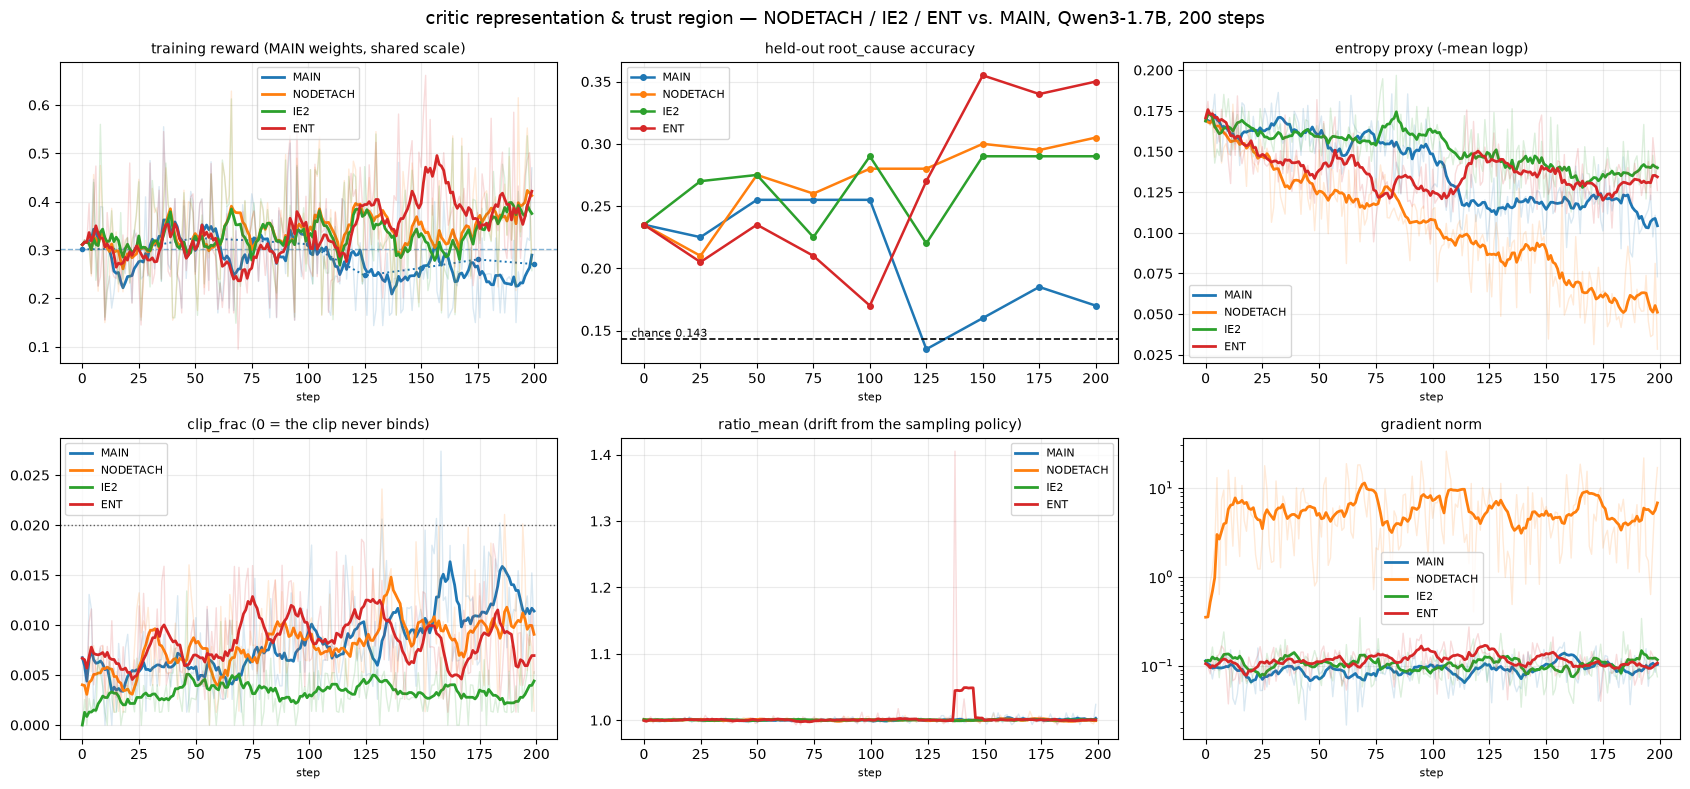

In [5]:
import matplotlib.pyplot as plt
import numpy as np


def load_jsonl(path):
    path = Path(path)
    return [json.loads(l) for l in path.read_text().splitlines() if l.strip()] if path.exists() else []


def smooth(values, window=9):
    return [sum(values[max(0, i - window + 1):i + 1]) / len(values[max(0, i - window + 1):i + 1])
            for i in range(len(values))]


ALL_RUNS = {"MAIN": MAIN_RUN}
ALL_RUNS.update({name: out for name, (_, out) in NEW.items()})
RUNS = {k: v for k, v in ALL_RUNS.items() if (v / "metrics.jsonl").exists()}
if len(RUNS) < len(ALL_RUNS):
    print("not run yet, skipped: " + ", ".join(k for k in ALL_RUNS if k not in RUNS) + "\n")

DATA = {name: (load_jsonl(run / "metrics.jsonl"), load_jsonl(run / "eval.jsonl"),
               json.loads((run / "config.json").read_text()))
        for name, run in RUNS.items()}
COLOUR = {name: f"C{i}" for i, name in enumerate(ALL_RUNS)}
CHANCE_CAUSE = 1 / 7

PANELS = (
    ("reward_mean",   "training reward (MAIN weights, shared scale)", False, False),
    ("cause_acc",     "held-out root_cause accuracy",                 False, True),
    ("entropy_proxy", "entropy proxy (-mean logp)",                   False, False),
    ("clip_frac",     "clip_frac (0 = the clip never binds)",         False, False),
    ("ratio_mean",    "ratio_mean (drift from the sampling policy)",  False, False),
    ("grad_norm",     "gradient norm",                                True,  False),
)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (key, title, log, from_eval) in zip(axes.flat, PANELS):
    for name, (rows, evals, cfg_run) in DATA.items():
        c = COLOUR[name]
        if from_eval:
            ax.plot([e["step"] for e in evals], [e[key] for e in evals],
                    marker="o", markersize=4, linewidth=1.8, color=c, label=name)
        else:
            steps = [r["step"] for r in rows]
            values = [float(r[key]) for r in rows]
            ax.plot(steps, values, alpha=0.16, linewidth=1, color=c)
            ax.plot(steps, smooth(values), linewidth=2, color=c, label=name)
        if key == "reward_mean" and name == "MAIN":
            frozen = ppo_ac.value_init_bias_for(cfg_run["model"], cfg_run["weights"])
            ax.axhline(frozen, linestyle="--", linewidth=1, color=c, alpha=0.55)
            ax.plot([e["step"] for e in evals], [e["reward"] for e in evals],
                    marker="o", markersize=3, linestyle=":", linewidth=1.4, color=c)
    if key == "cause_acc":
        ax.axhline(CHANCE_CAUSE, linestyle="--", linewidth=1.2, color="k")
        ax.annotate(f"chance {CHANCE_CAUSE:.3f}", xy=(0.02, CHANCE_CAUSE),
                    xycoords=("axes fraction", "data"), fontsize=8, va="bottom")
    if key == "clip_frac":
        ax.axhline(0.02, linestyle=":", linewidth=1, color="k", alpha=0.6)
    if log:
        ax.set_yscale("log")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("critic representation & trust region — NODETACH / IE2 / ENT vs. MAIN, "
             "Qwen3-1.7B, 200 steps", fontsize=13)
fig.tight_layout()
fig.savefig(HERE / "runs" / "critic_and_trust_region.png", dpi=140)

for name, (rows, evals, _) in DATA.items():
    if not evals:
        continue
    first, last = evals[0], evals[-1]
    peak = max(evals, key=lambda e: e["cause_acc"])
    print(f"{name:9s} cause_acc  step 0 {first['cause_acc']:.3f}  ->  step {last['step']} "
          f"{last['cause_acc']:.3f}   (peak {peak['cause_acc']:.3f} @ {peak['step']})")

## The critic panels — Q1's answer

`value_ev` is out-of-sample (the head as it stood *before* the batch was fitted, which is
what GAE actually built the advantages from); `value_ev_fit` is in-sample, after the
critic's updates; `value_std` is the within-batch spread of `V`; the last panel is
`adv_std / |adv_mean|`, the fraction of the advantage that is genuinely per-token rather
than a scalar broadcast to the whole sequence — the method's entire claim over GRPO, and
6.4% before the notebook-02 fixes.

**`NODETACH` against `MAIN` is the comparison.** `IE2` and `ENT` keep `value_detach=True`,
so their critic path is identical to MAIN's and they are here only to show the trust-region
levers did not disturb it. Steps where every sequence in the batch drew nearly the same
reward have no return variance and `value_ev` is *undefined* there, not bad — those are
dropped before smoothing and counted in each panel title.

run          value_ev    ev_fit  value_std  per-token   undef
MAIN          +0.0091   +0.0142     0.0422        46%      28
NODETACH      +0.0160   +0.0160     0.0511        54%       6
IE2           +0.0104   +0.0189     0.0487        67%       8
ENT           +0.0016   +0.0102     0.0474        46%       9


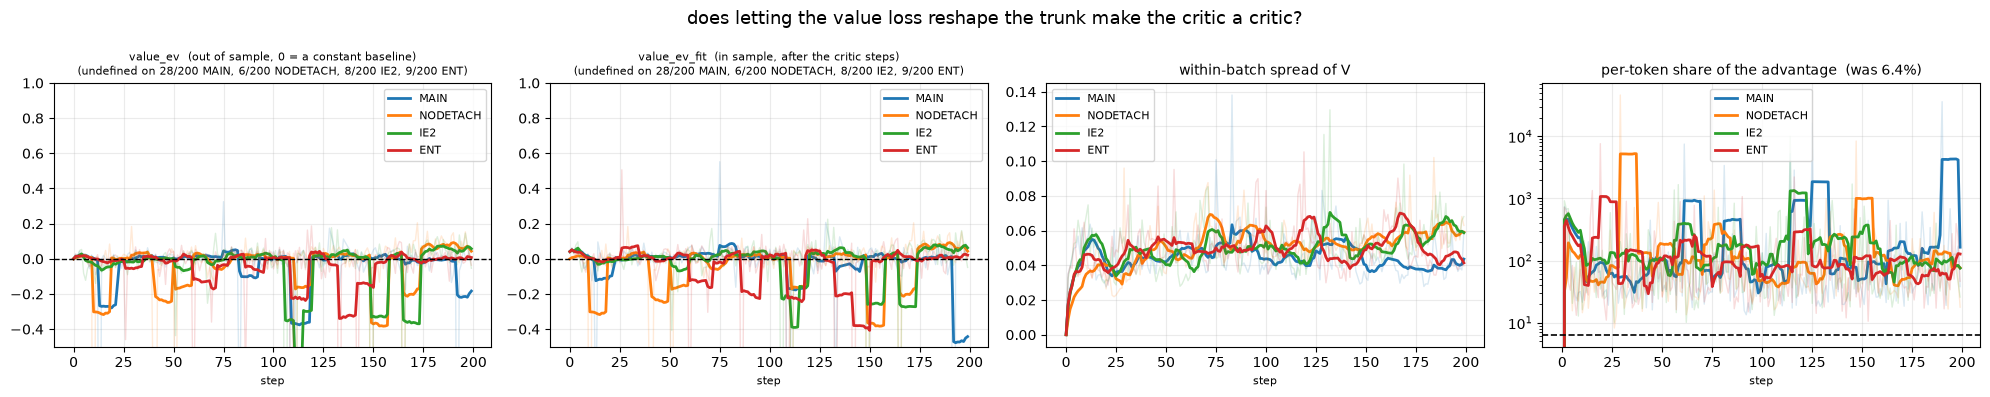

In [6]:
CRITIC_PANELS = (
    ("value_ev",     "value_ev  (out of sample, 0 = a constant baseline)"),
    ("value_ev_fit", "value_ev_fit  (in sample, after the critic steps)"),
    ("value_std",    "within-batch spread of V"),
    ("__pertoken__", "per-token share of the advantage  (was 6.4%)"),
)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (key, title) in zip(axes, CRITIC_PANELS):
    dropped = {}
    for name, (rows, _, _) in DATA.items():
        c = COLOUR[name]
        if key == "__pertoken__":
            pts = [(r["step"], 100 * r["adv_std"] / max(abs(r["adv_mean"]), 1e-9)) for r in rows]
        else:
            pts = [(r["step"], float(r[key])) for r in rows
                   if r.get(key) is not None and r["reward_max"] - r["reward_mean"] >= 0.05]
        steps, values = [s for s, _ in pts], [v for _, v in pts]
        dropped[name] = len(rows) - len(pts)
        ax.plot(steps, values, alpha=0.16, linewidth=1, color=c)
        ax.plot(steps, smooth(values), linewidth=2, color=c, label=name)
    if key.startswith("value_ev"):
        ax.axhline(0.0, linestyle="--", linewidth=1, color="k")
        ax.set_ylim(-0.5, 1.0)
    if key == "__pertoken__":
        ax.axhline(6.4, linestyle="--", linewidth=1.2, color="k")
        ax.set_yscale("log")
    if key.startswith("value_ev") and any(dropped.values()):
        ax.set_title(f"{title}\n(undefined on "
                     + ", ".join(f"{v}/{len(DATA[k][0])} {k}" for k, v in dropped.items() if v)
                     + ")", fontsize=8)
    else:
        ax.set_title(title, fontsize=10)
    ax.set_xlabel("step", fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle("does letting the value loss reshape the trunk make the critic a critic?", fontsize=13)
fig.tight_layout()
fig.savefig(HERE / "runs" / "critic_nodetach.png", dpi=140)

print(f"{'run':<10}{'value_ev':>11}{'ev_fit':>10}{'value_std':>11}{'per-token':>11}{'undef':>8}")
for name, (rows, _, _) in DATA.items():
    ok = [r for r in rows if r["reward_max"] - r["reward_mean"] >= 0.05]
    med = lambda k, src: float(np.median([r[k] for r in src if r.get(k) is not None])) if src else float("nan")
    pt = float(np.median([r["adv_std"] / max(abs(r["adv_mean"]), 1e-9) for r in rows]))
    print(f"{name:<10}{med('value_ev', ok):>+11.4f}{med('value_ev_fit', ok):>+10.4f}"
          f"{med('value_std', rows):>11.4f}{pt * 100:>10.0f}%{len(rows) - len(ok):>8d}")

## The trust-region table — Q2's answer

`clip_frac` and the `ratio_mean` spread say whether the clip did anything; the entropy
columns say whether the collapse was arrested; `cause_acc` says whether it cost anything on
the held-out task. `policy_entropy` is populated only for `ENT` (it is written to the
metrics only when `entropy_coef > 0`).

In [7]:
def series(rows, key):
    return [r[key] for r in rows if r.get(key) is not None]

print(f"{'run':<10}{'clip_frac':>11}{'ratio [min, max]':>22}"
      f"{'entropy 0->last':>18}{'H_policy 0->last':>18}{'cause 0->200':>15}")
print("-" * 94)
for name, (rows, evals, _) in DATA.items():
    if not rows:
        continue
    cf = np.median(series(rows, "clip_frac"))
    rm = series(rows, "ratio_mean")
    ep = series(rows, "entropy_proxy")
    pe = series(rows, "policy_entropy")
    ep_txt = f"{ep[0]:.3f}->{ep[-1]:.3f}" if ep else "-"
    pe_txt = f"{pe[0]:.3f}->{pe[-1]:.3f}" if pe else "-"
    cause = f"{evals[0]['cause_acc']:.3f}->{evals[-1]['cause_acc']:.3f}" if evals else "-"
    print(f"{name:<10}{cf:>11.4f}{f'[{min(rm):.3f}, {max(rm):.3f}]':>22}"
          f"{ep_txt:>18}{pe_txt:>18}{cause:>15}")

print("\nMAIN reference (notebook 02): clip_frac 0.008, ratio in [0.993, 1.024], "
      "entropy 0.169->0.073, cause 0.235->0.170.")

run         clip_frac      ratio [min, max]   entropy 0->last  H_policy 0->last   cause 0->200
----------------------------------------------------------------------------------------------
MAIN           0.0077        [0.993, 1.024]      0.169->0.073                 -   0.235->0.170
NODETACH       0.0078        [0.994, 1.013]      0.169->0.028                 -   0.235->0.305
IE2            0.0027        [0.996, 1.004]      0.169->0.141                 -   0.235->0.290
ENT            0.0079        [0.993, 1.405]      0.171->0.126      0.163->0.124   0.235->0.350

MAIN reference (notebook 02): clip_frac 0.008, ratio in [0.993, 1.024], entropy 0.169->0.073, cause 0.235->0.170.


## The paired test

`cause_acc` deltas quoted from aggregates are the wrong test — the independent-sample SE on
a proportion near 0.26 over 200 cases is 0.031. The evaluations are the **same 200 dev
cases, same order, greedy**, so almost every case is answered identically and only the
disagreements carry information. McNemar's exact test uses exactly those.

`runs/paired/base.json` (the frozen policy) and `runs/paired/main.json` were written by
notebook 02; the `split_sha256` guard confirms they are the same split before comparing.
This cell adds one greedy evaluation per new adapter.

In [8]:
import hashlib
from eval import generate_hf, summarise

PAIRED = HERE / "runs" / "paired"
PAIRED.mkdir(parents=True, exist_ok=True)

DEV = ppo_ac.DATA / "dev.jsonl"
SPLIT_SHA = hashlib.sha256(DEV.read_bytes()).hexdigest()
EVAL_CASES = 200
dev_cases = [json.loads(l) for l in DEV.read_text().splitlines()][:EVAL_CASES]

POLICIES = {name.lower(): out / "adapter"
            for name, (_, out) in NEW.items() if (out / "adapter").exists()}
for name, adapter in POLICIES.items():
    dest = PAIRED / f"{name}.json"
    if dest.exists():
        print(f"{dest.name}: already written, skipping")
        continue
    results = generate_hf(
        dev_cases, model="Qwen/Qwen3-1.7B", device=resolve_device("auto"), dtype="bfloat16",
        n=1, temperature=0.0, max_tokens=640, seed=0, batch_size=32,
        adapter=str(adapter), prompt_version=ppo_ac.PROMPT_VERSION,
    )
    overall = summarise(results, ppo_ac.WEIGHT_SETS["MAIN"])
    dest.write_text(json.dumps({
        "model": "Qwen/Qwen3-1.7B", "backend": "hf", "split": "dev", "split_sha256": SPLIT_SHA,
        "prompt_version": ppo_ac.PROMPT_VERSION, "weights": "MAIN", "mode": "greedy", "k": 1,
        "temperature": 0.0, "max_tokens": 640, "seed": 0, "adapter": str(adapter), "overall": overall,
    }, indent=2, default=str) + "\n")
    print(f"  {name:9s} reward {overall['reward']:.4f}  cause {overall['cause_acc']:.3f}  -> {dest.name}")
    torch.cuda.empty_cache()

nodetach.json: already written, skipping
ie2.json: already written, skipping
ent.json: already written, skipping


In [9]:
from paired_test import exact_binomial_two_sided


def per_case(name):
    payload = json.loads((PAIRED / f"{name}.json").read_text())
    if payload["split_sha256"] != SPLIT_SHA:
        raise SystemExit(f"{name} evaluated a different split; not comparable")
    return {r["id"]: r for r in payload["overall"]["per_case"]}


def mcnemar(before, after, metric="cause"):
    a, z = per_case(before), per_case(after)
    shared = sorted(set(a) & set(z))
    lost = [i for i in shared if a[i][metric] and not z[i][metric]]
    gained = [i for i in shared if not a[i][metric] and z[i][metric]]
    return {"before": sum(bool(a[i][metric]) for i in shared) / len(shared),
            "after": sum(bool(z[i][metric]) for i in shared) / len(shared),
            "lost": len(lost), "gained": len(gained),
            "discordant": len(lost) + len(gained),
            "p": exact_binomial_two_sided(len(lost), len(gained))}


have = [n for n in ("base", "main", "nodetach", "ie2", "ent") if (PAIRED / f"{n}.json").exists()]
comparisons = [("base", t, f"frozen -> {t.upper()}") for t in have if t not in ("base", "main")]
comparisons += [("main", t, f"MAIN -> {t.upper()}") for t in have if t not in ("base", "main")]

print("McNemar's exact test on `cause`, 200 paired dev cases, greedy\n")
head = f"  {'comparison':<22}{'before':>8}{'after':>8}{'gained':>8}{'lost':>7}{'discord':>9}{'p':>10}"
print(head + "\n  " + "-" * (len(head) - 2))
for before, after, label in comparisons:
    if before not in have:
        print(f"  {label:<22}   {before}.json missing — run notebook 02's paired cell")
        continue
    r = mcnemar(before, after)
    print(f"  {label:<22}{r['before']:>8.3f}{r['after']:>8.3f}{r['gained']:>8d}"
          f"{r['lost']:>7d}{r['discordant']:>9d}{r['p']:>10.4f}")
print("\n  Only the discordant pairs carry information; p > 0.05 = not distinguishable from a coin flip.")

McNemar's exact test on `cause`, 200 paired dev cases, greedy

  comparison              before   after  gained   lost  discord         p
  ------------------------------------------------------------------------
  frozen -> NODETACH       0.235   0.305      16      2       18    0.0013
  frozen -> IE2            0.235   0.290      13      2       15    0.0074
  frozen -> ENT            0.235   0.350      54     31       85    0.0165
  MAIN -> NODETACH         0.170   0.305      60     33       93    0.0067
  MAIN -> IE2              0.170   0.290      58     34       92    0.0160
  MAIN -> ENT              0.170   0.350      45      9       54    0.0000

  Only the discordant pairs carry information; p > 0.05 = not distinguishable from a coin flip.


## What this round showed

Every one of the three single-knob changes beat the frozen policy on the paired McNemar
test (p = 0.0013 / 0.0074 / 0.0165) **and** beat notebook 02's `MAIN`. `MAIN` is confirmed
the worst of the four: the only run whose held-out `cause_acc` *fell* (0.235 → 0.170) and
the only one to dip below the 1/7 chance rate (0.135 at step 125). The notebook-02
regression was real, and both diagnosed causes had fixes that worked.

**Q1 — the critic: a weak yes, not a fix.** `--no-value-detach` moved out-of-sample
`value_ev` from +0.009 to **+0.016** and cut degenerate batches from 28/200 to 6/200, both
in the direction the hypothesis predicted — the last-layer hidden states do not *already*
encode the return, and the trunk bends a little toward encoding it. But +0.016 is still a
critic that explains ~2% of the return variance; `value_std` only widened 0.042 → 0.051.
The representation was *part* of the constraint, not the whole of it. And `NODETACH`'s
policy gains (`cause_acc` 0.235 → 0.305, `flags_acc` → 0.417) are confounded by the value
loss reshaping the trunk — not a clean method comparison, exactly as flagged going in.

**Q2 — the trust region: the entropy bonus wins.**

| | `clip_frac` (max) | `ratio_mean` (max) | entropy proxy 0→last | held-out `cause_acc` 0→200 |
| --- | --- | --- | --- | --- |
| `MAIN` | 0.027 | 1.024 | 0.169 → 0.073 | 0.235 → **0.170** |
| `IE2` (`inner_epochs` 4→2) | 0.013 | 1.004 | 0.169 → 0.141 | 0.235 → 0.290 |
| `ENT` (`entropy_coef` 0.005) | 0.019 | **1.405** | 0.171 → 0.124 | 0.235 → **0.350** |

* `IE2` arrested the entropy collapse (0.141 vs `MAIN`'s 0.073) and improved the task — but
  by engaging the clip *less*, not more (`clip_frac` and `ratio` both fell). The gain came
  from cutting unrestrained updates from four to two: `inner_epochs=4` was simply too many.
* `ENT` is the only run where the trust region did anything at all: `ratio_mean` reached
  **1.405**, well outside the ±0.2 band, so the clip actually bound. Best held-out result
  of any run in this series — `cause_acc` 0.235 → 0.350, `flags_acc` 0.323 → 0.610,
  McNemar `MAIN → ENT` p < 0.0001 (45 gained, 9 lost). `entropy_coef` is now a real dial;
  0.005 is a floor found by one blown run at 0.05 (it swamped the reward gradient and drove
  the policy into 300-token garbage), not a tuned value.

**Scope, unchanged.** One seed, `MAIN` weights, 200 steps, three single-knob departures
from notebook 02. `numeric_acc` still wanders 0.02–0.07 (a handful of hits out of 600) and
exact match is 0.000 at every evaluation point across all three runs — none of this is
arithmetic, it is a better prior over seven labels. Nothing here speaks to a second seed,
a second split, or the sealed `test.jsonl`.

---

*`ppo_ac.py` picked up four corrections while these runs executed: `Config.entropy_coef` /
`token_entropy` / the bonus term (the feature), plus three latent bugs from commit
`58833d3` that these runs were the first to hit — `best` referenced before assignment in
the step-0 eval, `value_ev_gain` and the progress print not handling the `None` that
`critic_fit` returns on a degenerate batch, and `rollout` not surviving a completion the
scorer cannot parse. All are on paths the committed `MAIN`/`ABLATE`/`PROBE` runs never
exercised; `entropy_coef=0.0` leaves those runs bit-identical.*